# Visualise data from ArcticDB

Run these cells from the Bluegrey repo with the `bluegrey` conda environment active.

Import ArcticDB. Import Path and sys to be able to find src/config.py and import the settings there.

In [1]:
# --- import ArcticDB module for client setup ---
from arcticdb import Arctic

# --- Modules to manage directories and paths ---
from pathlib import Path # -- for handling filesystem paths
import sys # -- for managing the Python path to ensure project modules can be imported

# --- Ensure repo root is on sys.path so that src/config.py can be imported ---
ROOT_DIR = Path.cwd()

while not (ROOT_DIR / "src").exists(): # -- traverse up the directory tree until we find a directory containing 'src/'
    if ROOT_DIR.parent == ROOT_DIR: # -- if we reach the root of the filesystem without finding 'src/', raise an error and exit to avoid infinite loop
        raise RuntimeError("Could not find repo root containing 'src/'")
    ROOT_DIR = ROOT_DIR.parent

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR)) # -- add repo root to sys.path at the start (to be read first) for module imports

# --- Now safe to import project config ---
from src import config


Connect to the ArcticDB database.

In [2]:
store = Arctic(config.ARCTIC_PATH)  # -- connect to ArcticDB store using path from config.

# If you run this line more than once you'll get a warning that the store is already initialized. You can ignore that if you're just running this notebook multiple times.

## --- Set the market & ticker frequency ---

In [4]:
# What market do you want to see? i.e. "fx", "equity", "crypto", "options", "indices".
market = "equity"

# What frequency do you want to see? i.e. "sec", "min", "hour", "day", "week", "month", "quarter", "year".
freq = "day"

Build the library name from asset type and frequency.
<br>
Load the corresponding dataset from the config.

In [5]:
# Combine to get the library name, e.g. "fx_min"Arctic
lib_name = f"{market}_{freq}"

lib = store[config.LIBS[lib_name]]  # -- access the specific library for minute-level FX data as defined in config

See what symbols are in the library

In [8]:
symbols = sorted(lib.list_symbols()) # -- get sorted list of all symbols in the library
print(symbols)

# # Uncomment the following to see the symbols as an array
# import numpy as np
# np.array(symbols)

['ECH']


##  --- Set symbol ---

In [9]:
# Choose a symbol to visualize, e.g. "C:EURUSD", or "X:BTCUSD" for crypto. Make sure it exists in the library.
# symbol = "C:EURUSD" # -- example for FX
# symbol = "X:BTCUSD" # -- example for crypto
symbol = "ECH"

Put the desired data from the Arctic database into a dataframe

In [10]:
# Fetch the data for the chosen symbol. This will return a DataFrame with columns like 'open', 'high', 'low', 'close', 'volume', etc.
df = lib.read(symbol).data
# df.head()
df

,open,high,low,close,volume,vwap
timestamp,,,,,,
2024-05-08 04:00:00,27.68,27.850,27.540,27.69,1.059810e+05,27.6982
2024-05-09 04:00:00,27.81,28.290,27.810,28.16,3.990700e+05,28.1343
2024-05-10 04:00:00,28.34,28.500,28.070,28.12,1.969670e+05,28.1706
2024-05-13 04:00:00,28.33,28.480,28.240,28.40,2.403470e+05,28.3993
2024-05-14 04:00:00,28.52,28.860,28.515,28.83,2.648930e+05,28.7050
...,...,...,...,...,...,...
2026-05-01 04:00:00,41.83,41.830,41.475,41.52,2.697957e+05,41.6077
2026-05-04 04:00:00,41.27,41.470,39.950,40.11,1.049606e+06,40.4627
2026-05-05 04:00:00,40.59,41.180,40.380,40.52,4.145394e+05,40.8060


Review brief statistics of dataframe

In [11]:
# --- Read and display basic statistics for the FX data ---
print("Data Summary Statistics:")
print(df.describe())
print("\nData Info:")
print(df.info())

Data Summary Statistics:
             open        high         low       close        volume  \
count  501.000000  501.000000  501.000000  501.000000  5.010000e+02   
mean    31.942335   32.194408   31.676590   31.931587  5.003794e+05   
std      6.123222    6.193309    6.009699    6.105010  4.530771e+05   
min     23.850000   24.530000   23.790000   24.310000  5.489400e+04   
25%     26.530000   26.710000   26.405000   26.570000  2.120960e+05   
50%     30.390000   30.600000   30.260000   30.390000  3.292920e+05   
75%     35.350000   35.490000   35.130000   35.340000  6.433150e+05   
max     47.770000   47.845000   47.030000   47.370000  3.060313e+06   

             vwap  
count  501.000000  
mean    31.935051  
std      6.097734  
min     24.282400  
25%     26.571100  
50%     30.436500  
75%     35.317400  
max     47.341000  

Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 501 entries, 2024-05-08 04:00:00 to 2026-05-07 04:00:00
Data columns (total 6 columns):
 #

Select a certain time-range of data to see

In [12]:
from pandas import to_datetime as to_datetime

initial_time = "2026-01-01"
final_time = "2026-02-01"
initial_final_range= (to_datetime(initial_time), to_datetime(final_time))

df_range = lib.read(
    symbol,
    date_range = initial_final_range
).data

# df_range.head()
df_range

,open,high,low,close,volume,vwap
timestamp,,,,,,
2026-01-02 05:00:00,40.52,40.6099,39.9800,40.370,543285.0,40.2744
2026-01-05 05:00:00,40.69,41.6000,40.5850,41.600,1545587.0,41.0848
2026-01-06 05:00:00,42.35,43.2200,42.3300,42.550,1426824.0,42.7216
2026-01-07 05:00:00,42.52,42.5200,42.0600,42.390,398186.0,42.3434
2026-01-08 05:00:00,42.42,42.7799,42.2600,42.750,379316.0,42.5675
2026-01-09 05:00:00,42.87,42.9300,42.5300,42.850,314533.0,42.7443
2026-01-12 05:00:00,43.55,43.9850,43.3900,43.870,891504.0,43.7364
2026-01-13 05:00:00,44.23,44.4900,44.0200,44.340,927403.0,44.2776
2026-01-14 05:00:00,44.59,44.7300,44.2500,44.510,1108250.0,44.5026


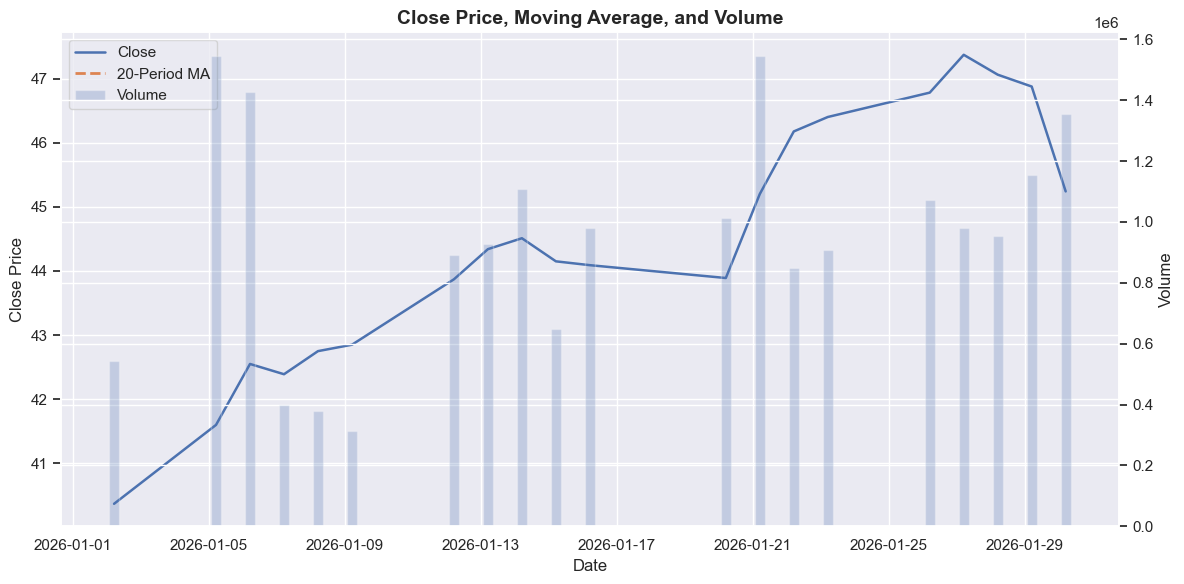

In [13]:
# Plot close, rolling MA, and volume using seaborn

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure datetime index
df_range.index = pd.to_datetime(df_range.index)

# Rolling average
ma_window = 20
df_range[f'close_ma_{ma_window}'] = df_range['close'].rolling(window=ma_window).mean()

# Seaborn styling
sns.set_theme(style="darkgrid", context="notebook")

fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Close + MA (seaborn lines) ---
sns.lineplot(
    x=df_range.index,
    y=df_range['close'],
    ax=ax1,
    label='Close',
    linewidth=1.8
)

sns.lineplot(
    x=df_range.index,
    y=df_range[f'close_ma_{ma_window}'],
    ax=ax1,
    label=f'{ma_window}-Period MA',
    linewidth=2.0,
    linestyle='--'
)

ax1.set_xlabel('Date')
ax1.set_ylabel('Close Price')

# --- Volume (secondary axis, matplotlib bar) ---
ax2 = ax1.twinx()
ax2.bar(
    df_range.index,
    df_range['volume'],
    width=0.3,
    alpha=0.25,
    label='Volume'
)
ax2.set_ylabel('Volume')

# Title
ax1.set_title('Close Price, Moving Average, and Volume', fontsize=14, weight='bold')

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# Formatting
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()